## HDBSCAN Clustering

### 1. Imports

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import umap
import hdbscan

print('All imports successful!')

All imports successful!


### Model Configuration

In [15]:
# Audio features
AUDIO_FEATURES = [
    'energy', 'tempo', 'danceability', 'loudness',
    'liveness', 'valence', 'speechiness',
    'instrumentalness', 'acousticness', 'mode',
]

# Genre column prefix 
GENRE_COLS_PREFIX = 'playlist_genre_'

# Genre weight
GENRE_WEIGHT = 1

# UMAP hyperparameters
UMAP_N_COMPONENTS = 15   # target dimensionality
UMAP_N_NEIGHBORS  = 20   # lower = more local structure

# ── HDBSCAN hyperparameters ──────────────────────────────────────────────────
HDBSCAN_MIN_CLUSTER_SIZE = 30   # minimum songs per cluster
HDBSCAN_MIN_SAMPLES      = 5    # controls noise sensitivity



### Load data

In [16]:
DATA_PATH = 'songs.csv'
df = pd.read_csv(DATA_PATH)
df.head(3)

,track_id,energy,tempo,danceability,loudness,liveness,valence,track_artist,speechiness,track_popularity,...,playlist_genre_pop,playlist_genre_punk,playlist_genre_r&b,playlist_genre_reggae,playlist_genre_rock,playlist_genre_soca,playlist_genre_soul,playlist_genre_turkish,playlist_genre_wellness,playlist_genre_world
0,00Coyxt9mTec1acC52qtWa,0.736420,0.329870,0.634822,0.898334,0.083507,0.502,TAEIL,0.009170,0.55,...,0,0,0,0,0,0,0,0,0,0
1,00DPAwQ3NkWs6PZKNxy7Pi,0.899779,0.433735,0.782632,0.880394,0.168058,0.675,Olamilekan Akamo,0.069716,0.30,...,0,0,0,0,0,0,0,0,0,0
2,00Gbi2ytn6ZmA1ObVcPT93,0.928843,0.454284,0.579394,0.866443,0.670146,0.678,Smith & Thell,0.024307,0.31,...,1,0,0,0,0,0,0,0,0,0


### Select Features

In [17]:
# Collect and down-weight genre columns
genre_cols = [c for c in df.columns if c.startswith(GENRE_COLS_PREFIX)]
genre_weighted = df[genre_cols].fillna(0).values.astype(float) * GENRE_WEIGHT

# Final feature matrix
feature_matrix = np.hstack([df[AUDIO_FEATURES], genre_weighted])

print(f'Feature matrix: {feature_matrix.shape[0]} songs × {feature_matrix.shape[1]} features')
print(f'  Audio features : {len(AUDIO_FEATURES)}')
print(f'  Genre features : {len(genre_cols)} (weighted × {GENRE_WEIGHT})')

Feature matrix: 4493 songs × 45 features
  Audio features : 10
  Genre features : 35 (weighted × 1)


### UMAP — dimensionality reduction

In [18]:
print('Running UMAP... (takes ~30s on 4500 songs)')

reducer = umap.UMAP(
    n_components=UMAP_N_COMPONENTS,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=0.0, # pack similar songs tightly — better for HDBSCAN
    metric='cosine',
    random_state=42,
)
embedding = reducer.fit_transform(feature_matrix)

print(f'Embedding shape: {embedding.shape}')

Running UMAP... (takes ~30s on 4500 songs)
Embedding shape: (4493, 15)


### Visualise the 2D UMAP projection
Reduce to 2D just for plotting — the 15D embedding is used for actual clustering.

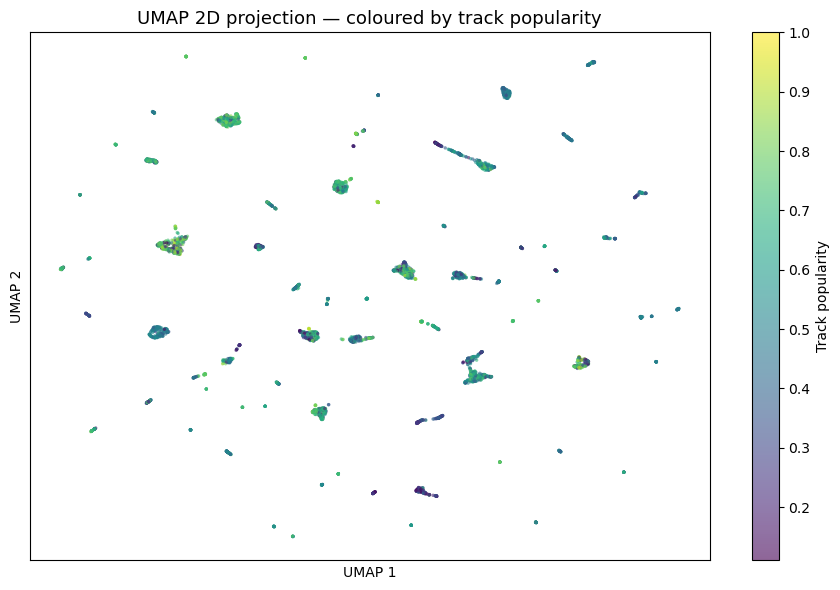

In [19]:
reducer_2d = umap.UMAP(n_components=2, n_neighbors=UMAP_N_NEIGHBORS,
                       min_dist=0.1, metric='cosine', random_state=42)
                       
emb_2d = reducer_2d.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                     c=df['track_popularity'], cmap='viridis',
                     s=6, alpha=0.6, linewidths=0)
plt.colorbar(scatter, ax=ax, label='Track popularity')
ax.set_title('UMAP 2D projection — coloured by track popularity', fontsize=13)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

### HDBSCAN clustering

Key parameters:
- **`min_cluster_size`** — smallest grouping HDBSCAN will consider a cluster. Raise it for fewer, broader clusters.
- **`min_samples`** — controls how conservative noise detection is. Higher = more noise points.
- Songs that don't belong to any cluster are labelled **−1** (noise). These are acoustically unique tracks — useful to know about, not a problem.

In [20]:
print('Running HDBSCAN...')

from sklearn.metrics import silhouette_score
import numpy as np

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
    min_samples=HDBSCAN_MIN_SAMPLES,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)

labels = clusterer.fit_predict(embedding)

df['cluster']      = labels
df['cluster_prob'] = clusterer.probabilities_

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()

# --- Silhouette score (exclude noise) ---
mask = labels != -1

if np.sum(mask) > 1 and n_clusters > 1:
    try:
        sil_score = silhouette_score(
            embedding[mask],
            labels[mask]
        )
    except:
        sil_score = np.nan
else:
    sil_score = np.nan

# --- Output ---
print(f'Clusters found : {n_clusters}')
print(f'Noise points   : {n_noise} ({n_noise / len(labels) * 100:.1f}%)')
print(f'Clustered songs: {len(labels) - n_noise} ({(len(labels) - n_noise) / len(labels) * 100:.1f}%)')
print(f'Silhouette     : {sil_score:.4f}' if not np.isnan(sil_score) else 'Silhouette     : N/A')

Running HDBSCAN...
Clusters found : 43
Noise points   : 204 (4.5%)
Clustered songs: 4289 (95.5%)
Silhouette     : 0.8727


### Visualise clusters on 2D UMAP

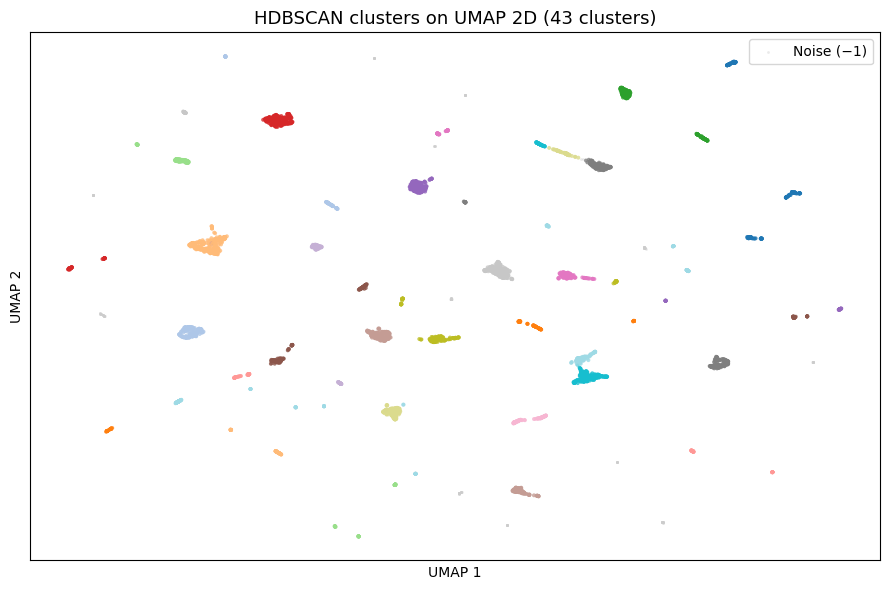

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))

# Plot noise points first (grey, smaller)
noise_mask = labels == -1
ax.scatter(emb_2d[noise_mask, 0], emb_2d[noise_mask, 1],
           c='#cccccc', s=4, alpha=0.4, label='Noise (−1)', linewidths=0)

# Plot clustered points coloured by cluster label
clustered_mask = ~noise_mask
scatter = ax.scatter(emb_2d[clustered_mask, 0], emb_2d[clustered_mask, 1],
                     c=labels[clustered_mask], cmap='tab20',
                     s=8, alpha=0.8, linewidths=0)

ax.set_title(f'HDBSCAN clusters on UMAP 2D ({n_clusters} clusters)', fontsize=13)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

### Recommendation function

In [22]:
def recommend(
    track_name: str,
    n: int = 10,
    max_artist_popularity: float = 0.5,
    max_top_track_popularity: float = 0.5,
    same_cluster_only: bool = True,
) -> pd.DataFrame:
    
    # Find track
    matches = df[df['track_name'].str.lower() == track_name.lower()]
    if matches.empty:
        matches = df[df['track_name'].str.lower().str.contains(track_name.lower())]
    if matches.empty:
        raise ValueError(f"Track '{track_name}' not found in dataset.")

    seed_idx     = matches.index[0]
    seed_cluster = df.loc[seed_idx, 'cluster']
    seed_row     = df.loc[seed_idx]

    print(f"Seed track   : '{seed_row['track_name']}' by {seed_row['track_artist']}")
    print(f"Cluster      : {seed_cluster}")
    print(f"Popularity   : track={seed_row['track_popularity']:.2f}  "
          f"artist={seed_row['artist_popularity']:.2f}")

    # Build candidate pool
    if same_cluster_only and seed_cluster != -1:
        pool = df[(df['cluster'] == seed_cluster) & (df.index != seed_idx)]
    else:
        if seed_cluster == -1:
            print('  (Noise point — searching full dataset)')
        pool = df[df.index != seed_idx]

    # Filter by artist popularity
    pool = pool[pool['artist_popularity'] <= max_artist_popularity]
    pool = pool[pool['artist_top_track_popularity'] <= max_top_track_popularity]

    if pool.empty:
        print(f'  No candidates with artist_popularity ≤ {max_artist_popularity}')
        return pd.DataFrame()

    # Cosine similarity on original scaled feature matrix
    seed_vec  = feature_matrix[seed_idx].reshape(1, -1)
    pool_vecs = feature_matrix[pool.index]
    sims      = cosine_similarity(seed_vec, pool_vecs)[0]

    pool = pool.copy()
    pool['similarity'] = sims
    pool = pool.sort_values('similarity', ascending=False).head(n)

    return pool[[
        'track_name', 'track_artist', 'artist_popularity',
        'track_popularity', 'cluster', 'similarity',
        'energy', 'danceability', 'valence', 'tempo',
    ]].reset_index(drop=True)


print('recommend() function ready.')

recommend() function ready.


Get recommendations


In [23]:
SEED_TRACK = "Open Arms"
MAX_ARTIST_POPULARITY = 0.5 
MAX_TOP_TRACK_POPULARITY = 0.5
N_RECOMMENDATIONS = 10

recs = recommend(
    track_name=SEED_TRACK,
    n=N_RECOMMENDATIONS,
    max_artist_popularity=MAX_ARTIST_POPULARITY,
    max_top_track_popularity=MAX_TOP_TRACK_POPULARITY,
)
recs

Seed track   : 'Open Arms (feat. Travis Scott)' by SZA, Travis Scott
Cluster      : 6
Popularity   : track=0.80  artist=0.87


,track_name,track_artist,artist_popularity,track_popularity,cluster,similarity,energy,danceability,valence,tempo
0,Empire State Express,Son House,0.0,0.22,6,0.724598,0.416716,0.657646,0.649,0.266546
1,Statesboro Blues,Blind Willie McTell,0.0,0.31,6,0.724447,0.267387,0.558744,0.437,0.218899
2,Down The Dirt Road Blues,Charley Patton,0.0,0.24,6,0.716210,0.281418,0.450060,0.523,0.367139
3,Preachin' Blues,Son House,0.0,0.18,6,0.713885,0.349568,0.582654,0.231,0.642799
4,They're Red Hot - SA.2627-1,Robert Johnson,0.0,0.24,6,0.698230,0.244336,0.729377,0.734,0.344472
5,Cypress Grove Blues,"Skip James, Jack Owens",0.0,0.21,6,0.688078,0.121065,0.587001,0.568,0.281406
6,Hard Time Killing Floor Blues,Skip James,0.0,0.35,6,0.669995,0.070152,0.509836,0.265,0.155321
7,Black Betty,Lead Belly,0.0,0.34,6,0.664159,0.122067,0.713075,0.577,0.288555


In [24]:
#Hyperparameter tuning. 

param_grid = {
    "n_neighbors": [20, 30, 40, 50, 60, 70],
    "n_components": [15, 20, 30],
    "min_cluster_size": [20, 30, 40, 50, 60],
    "min_samples": [5]
}

def run_pipeline(feature_matrix, params):
    reducer = umap.UMAP(
        n_components=params["n_components"],
        n_neighbors=params["n_neighbors"],
        min_dist=0.0,
        metric='cosine',
        random_state=42,
    )
    embedding = reducer.fit_transform(feature_matrix)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=params["min_cluster_size"],
        min_samples=params["min_samples"],
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True,
    )

    labels = clusterer.fit_predict(embedding)

    # --- metrics ---
    mask = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if np.sum(mask) > 1 and n_clusters > 1:
        try:
            sil_score = silhouette_score(embedding[mask], labels[mask])
        except:
            sil_score = np.nan
    else:
        sil_score = np.nan

    return embedding, labels, sil_score, n_clusters

import itertools

results = []

for values in itertools.product(*param_grid.values()):
    params = dict(zip(param_grid.keys(), values))

    print(f"\nRunning: {params}")

    embedding, labels, sil_score, n_clusters = run_pipeline(feature_matrix, params)

    results.append({
        **params,
        "silhouette": sil_score,
        "n_clusters": n_clusters
    })

    print(f"Clusters: {n_clusters}, Silhouette: {sil_score}")



Running: {'n_neighbors': 20, 'n_components': 15, 'min_cluster_size': 20, 'min_samples': 5}
Clusters: 59, Silhouette: 0.8830521106719971

Running: {'n_neighbors': 20, 'n_components': 15, 'min_cluster_size': 30, 'min_samples': 5}
Clusters: 43, Silhouette: 0.8726558685302734

Running: {'n_neighbors': 20, 'n_components': 15, 'min_cluster_size': 40, 'min_samples': 5}
Clusters: 39, Silhouette: 0.8674235939979553

Running: {'n_neighbors': 20, 'n_components': 15, 'min_cluster_size': 50, 'min_samples': 5}
Clusters: 34, Silhouette: 0.835821270942688

Running: {'n_neighbors': 20, 'n_components': 15, 'min_cluster_size': 60, 'min_samples': 5}
Clusters: 29, Silhouette: 0.8232670426368713

Running: {'n_neighbors': 20, 'n_components': 20, 'min_cluster_size': 20, 'min_samples': 5}
Clusters: 60, Silhouette: 0.8907679319381714

Running: {'n_neighbors': 20, 'n_components': 20, 'min_cluster_size': 30, 'min_samples': 5}
Clusters: 42, Silhouette: 0.8882325887680054

Running: {'n_neighbors': 20, 'n_component

In [25]:
if params["n_components"] == 2:
    fig, ax = plt.subplots(figsize=(6, 5))

    noise_mask = labels == -1
    clustered_mask = ~noise_mask

    ax.scatter(embedding[noise_mask, 0], embedding[noise_mask, 1],
                c='#cccccc', s=4, alpha=0.4)

    ax.scatter(embedding[clustered_mask, 0], embedding[clustered_mask, 1],
                c=labels[clustered_mask], cmap='tab20',
                s=8, alpha=0.8)

    ax.set_title(f"{params} | Sil={sil_score:.3f}")
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()

In [26]:
import pandas as pd

results_df = pd.DataFrame(results)

best = results_df.sort_values("silhouette", ascending=False).head(5)
print(best)

    n_neighbors  n_components  min_cluster_size  min_samples  silhouette  \
55           50            30                20            5    0.902524   
75           70            15                20            5    0.900870   
56           50            30                30            5    0.899959   
25           30            30                20            5    0.899218   
35           40            20                20            5    0.899089   

    n_clusters  
55          56  
75          56  
56          46  
25          55  
35          57  


UMAP Notes:

n_neighbors - local/global tradeoff - Can see we get higher silhouette score with higer n_neighbors score. 

min_dist - controls how tightly UMAP can clump points togerther. Lower value = clumpier embeddings = good for clustering

n_components - determins the dimensionality of the data

metric -how distance is computed

